# Hafta 2 · Ders 4 — Rank ve Dört Temel Alt Uzay

> **Makine Öğrenmesi için Lineer Cebir** · ilk ilkelerden bir kurs
>
> *türet → uygula → görselleştir → doğrula → makine öğrenmesine bağla*

Ders 3'te bir matrisin uzayı **çökertebileceğini** gördük (sıfır determinant). Bu defter,
çökmenin gündeme getirdiği iki soruyu yanıtlar:

- **Her şey nereye düşer?** → **sütun uzayı** (ulaşılabilir çıktılar)
- **Ne sıfıra ezilir?** → **çekirdek uzayı (null space)** ($A$'nın yok ettiği yönler)

Transpozeleriyle birlikte bunlar, **dört temel alt uzayı** oluşturur. Sütun uzayının boyutu
**rank**tır — bir matristeki gerçek bağımsız yön sayısı ve verilerinizin gerçekten kaç bileşene
ihtiyaç duyduğuna karar verirken PCA'in gizlice tahmin ettiği nicelik.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from utils.linalg_viz import check

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.dpi"] = 110

## 1. Sütun uzayı — ulaşılabilir çıktılar

**Sütun uzayı** $C(A)$, $A$'nın sütunlarının gerenidir: $A\mathbf{x}$ olarak üretebileceğiniz tüm
vektörlerin kümesi. "$A\mathbf{x}=\mathbf{b}$ sistemi hangi $\mathbf{b}$'yi gerçekten
çözebilir?" sorusunu yanıtlar.

İki sütunu aynı yönü gösteren, rank-eksikli bir matris düşünün. $\mathbb{R}^2$'de yaşamasına rağmen,
sütun uzayı yalnızca bir **doğrudur** — yani çoğu hedef $\mathbf{b}$ ulaşılamazdır.

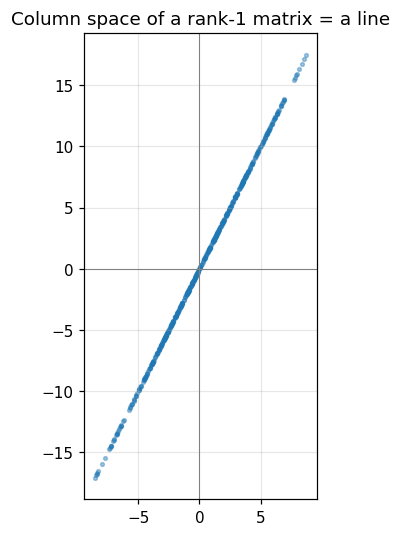

Every output lies on the line spanned by column 1 = [1. 2.]


In [2]:
A = np.array([[1.0, 2.0],
              [2.0, 4.0]])    # sütun 2 = 2 × sütun 1  → rank 1

rng = np.random.default_rng(0)
xs = rng.uniform(-3, 3, size=(500, 2))
outputs = xs @ A.T            # ulaşılabilir tüm A x

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(outputs[:, 0], outputs[:, 1], s=6, alpha=0.4, color="C0")
ax.set_title("Rank-1 bir matrisin sütun uzayı = bir doğru")
ax.axhline(0, color="grey", lw=0.7); ax.axvline(0, color="grey", lw=0.7)
ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
plt.show()

print("Her çıktı, sütun 1 tarafından gerilen doğru üzerindedir =", A[:, 0])

## 2. Çekirdek uzayı (null space) — yok edilen şey

**Çekirdek uzayı** $N(A)$, $A$'nın sıfıra gönderdiği vektörlerin kümesidir: $A\mathbf{x} = \mathbf{0}$
olan tüm $\mathbf{x}$'ler. Yukarıdaki rank-1 matris için, orijine çöken tüm bir girdi *doğrusu* vardır.
Bir çekirdek-uzayı vektörü kadar farklı olan herhangi iki girdi, **aynı çıktıyı** üretir — bu da
tam olarak rank-eksikli bir sistemin neden sonsuz sayıda çözüme (ya da hiç çözüme) sahip olduğudur.

Çekirdek uzayını SVD'den bulabiliriz (Hafta 6 ön gösterimi): sıfır tekil değere sahip sağ-tekil
vektörler onu gerer. Burada bunu doğrudan doğruluyoruz.

In [3]:
# A için çekirdek uzayı yönü: A x = 0'ı çöz  →  x ∝ (2, -1)
n = np.array([2.0, -1.0])
print("A @ n =", A @ n, " → sıfıra çöker, yani n çekirdek uzayındadır")

# n boyunca kaydırılmış herhangi bir girdi aynı çıktıyı verir
x = np.array([1.0, 1.0])
print("A @ x        =", A @ x)
print("A @ (x + 3n) =", A @ (x + 3 * n), " → özdeş çıktı")

A @ n = [0. 0.]  → collapses to zero, so n is in the null space
A @ x        = [3. 6.]
A @ (x + 3n) = [3. 6.]  → identical output


## 3. Rank — bağımsız yönleri saymak

**Rank**, sütun uzayının boyutudur: matrisin ulaşabileceği gerçekten bağımsız yön sayısı.
Bunu sıfırdan **satır indirgemesi** (gelecek hafta resmileştireceğimiz Gauss eleme) ile,
sıfır olmayan pivot satırlarını sayarak hesaplıyoruz.

In [4]:
def rank_by_elimination(M, tol=1e-9):
    M = np.asarray(M, float).copy()
    rows, cols = M.shape
    r = 0
    for col in range(cols):
        # `col` sütununda, r satırında ya da altında bir pivot bul
        pivot = None
        for i in range(r, rows):
            if abs(M[i, col]) > tol:
                pivot = i
                break
        if pivot is None:
            continue
        M[[r, pivot]] = M[[pivot, r]]            # pivot satırını yukarı taşı
        M[r] = M[r] / M[r, col]                  # pivotu normalleştir
        for i in range(rows):                    # sütunu başka yerlerde ele
            if i != r:
                M[i] = M[i] - M[i, col] * M[r]
        r += 1
    return r

tests = {
    "rank-1 (bağımlı sütunlar)": np.array([[1, 2], [2, 4]]),
    "tam rank 2":             np.array([[1, 2], [3, 4]]),
    "3x3 rank 2":              np.array([[1, 2, 3], [2, 4, 6], [1, 0, 1]]),
}
for name, M in tests.items():
    mine = rank_by_elimination(M)
    check(f"{name:<26}", mine, np.linalg.matrix_rank(M))

[PASS] rank-1 (dependent cols)          max|Δ| = 0.00e+00
[PASS] full rank 2                      max|Δ| = 0.00e+00
[PASS] 3x3 rank 2                       max|Δ| = 0.00e+00


## 4. Rank–boşluk (rank–nullity) teoremi

Sütun uzayının ve çekirdek uzayının boyutları bağımsız değildir — sütun sayısına eşit olacak şekilde
toplanmaları gerekir:

$$ \underbrace{\text{rank}(A)}_{\dim C(A)} + \underbrace{\text{boşluk}(A)}_{\dim N(A)} = n \quad(\text{sütun sayısı}) $$

Sezgisel olarak: her girdi boyutu ya *korunur* (çıktıya katkı sağlar, rank tarafından sayılır)
ya da *yok edilir* (sıfıra çöker, boşluk tarafından sayılır). Hiçbiri ikisi birden olamaz. Bu korunum
yasası, dört-alt-uzay resminin omurgasıdır.

In [5]:
def nullity(M, tol=1e-9):
    return M.shape[1] - rank_by_elimination(M, tol)

for name, M in tests.items():
    r, nul = rank_by_elimination(M), nullity(M)
    print(f"{name:<26}  rank={r}  boşluk={nul}  sütun={M.shape[1]}  → toplam={r+nul}")

rank-1 (dependent cols)     rank=1  nullity=1  cols=2  → sum=2
full rank 2                 rank=2  nullity=0  cols=2  → sum=2
3x3 rank 2                  rank=2  nullity=1  cols=3  → sum=3


## 5. Bunun makine öğrenmesinde karşımıza çıktığı yer

- **Çoklu eşdoğrusallık (multicollinearity).** Öznitelikler lineer bağımlı olduğunda, veri matrisi rank-eksiklidir.
  $X^\top X$ tekil hâle gelir ve sıradan en küçük karelerin tek bir çözümü yoktur — ridge regresyonunun
  pratik gerekçesi (Hafta 6).
- **Etkin boyutluluk.** Bir (merkezlenmiş) veri matrisinin rankı, verilerin gerçekten işgal ettiği
  boyut sayısıdır. PCA bu yönleri sıralar; düşük sayısal rank ⇒ agresif sıkıştırma güvenlidir.
- **Düşük-rank yapısı**, öneri sistemlerini, LoRA ince ayarını (fine-tuning) ve matris tamamlamayı çalıştırır —
  hepsi büyük bir matrisin gizlice küçük rankı olduğuna oynanan bahislerdir.

Gösterim: gereksiz bir sütunu olan bir öznitelik matrisi rank-eksiklidir.

In [6]:
rng = np.random.default_rng(1)
f1 = rng.normal(size=100)
f2 = rng.normal(size=100)
f3 = 2 * f1 - f2          # gereksiz: f1, f2'nin bir lineer kombinasyonu

X_good = np.column_stack([f1, f2])
X_bad  = np.column_stack([f1, f2, f3])

print("[f1, f2]'nin rankı       =", np.linalg.matrix_rank(X_good), " (sütun =", X_good.shape[1], ")")
print("[f1, f2, f3]'ün rankı    =", np.linalg.matrix_rank(X_bad),  " (sütun =", X_bad.shape[1], ")")
print("→ 3. öznitelik yeni bir yön eklemez; matris rank-eksiklidir.")

rank of [f1, f2]       = 2  (cols = 2 )
rank of [f1, f2, f3]   = 2  (cols = 3 )
→ the 3rd feature adds no new direction; the matrix is rank-deficient.


## Alıştırmalar

1. **Kasıtlı olarak rank-2, 3×3 bir matris oluşturun** ve `rank_by_elimination` ile doğrulayın.
2. **Çekirdek uzayı boyutu.** Tam satır rankına sahip bir $2\times 4$ matris için, rank–boşluk teoremini kullanarak boşluğu tahmin edin, ardından kontrol edin.
3. **Sütun rankına karşı satır rankı.** Birkaç rastgele matriste `rank(A) == rank(A.T)` olduğunu doğrulayın (satır rankı sütun rankına eşittir — derin ve aşikâr olmayan bir gerçek).

In [7]:
# === Çözümler (önce kendiniz deneyin!) ===

# 1.
M = np.array([[1, 0, 1], [0, 1, 1], [1, 1, 2]])   # satır3 = satır1 + satır2
print("rank =", rank_by_elimination(M), " (beklenen 2)")

# 2. tam satır rankı 2, n=4 sütun → boşluk = 4 - 2 = 2
B = np.array([[1, 0, 2, 1], [0, 1, 1, 3]], float)
print("boşluk =", nullity(B), " (beklenen 2)")

# 3.
rng = np.random.default_rng(7)
print("rastgele matrisler için satır rankı == sütun rankı:",
      all(np.linalg.matrix_rank(A := rng.normal(size=(4, 6))) ==
          np.linalg.matrix_rank(A.T) for _ in range(50)))

rank = 2  (expected 2)
nullity = 2  (expected 2)
row rank == col rank for random matrices: True


## Özet ve sırada ne var

Sütun uzayı = ulaşılabilir çıktılar, çekirdek uzayı = yok edilen girdiler, rank = bağımsız yönler
ve rank + boşluk = sütun sayısı. Bu, herhangi bir matrisin yapısal anatomisidir.

**Sırada — `05_gauss_eleme_lu.ipynb`:** rankı bulmak için kullandığımız satır indirgeme hilesini,
lineer sistemleri *çözmek* için tam, pivotlu bir algoritmaya dönüştürüyoruz — bilgisayarların gerçekte yaptığı şekilde.

---
*Makine Öğrenmesi için Lineer Cebir · Hafta 2 · Ders 4*